In [15]:
import torch
import numpy as np
import rasterio
from rasterio.windows import Window
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, SegformerForSemanticSegmentation
from tqdm import tqdm

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_id = "restor/tcd-segformer-mit-b2"
processor = AutoImageProcessor.from_pretrained(model_id)
image_path = 'dop10rgbi_32_280_5652_1_nw_2025.jp2'



In [2]:
model = SegformerForSemanticSegmentation.from_pretrained(model_id).to(device)
model.eval()

def read_rgb(src, window=None, scale_16bit=True):
  # read rgb bands in satellite img.
  img = src.read([1,2,3], window=window)
  # Move channel axis to last dimension: (H, W, 3)
  img = np.moveaxis(img, 0, -1)
  if scale_16bit and img.dtype == np.uint16:
    img = (img / 256).astype(np.uint8)
  return img

Loading weights: 100%|██████████| 380/380 [00:00<00:00, 1120.68it/s]


In [3]:
patch_size = 512

# Sliced Inference
with rasterio.open('dop10rgbi_32_280_5652_1_nw_2025.jp2') as src:
    h, w, patch_size = src.height, src.width, 512
    full_mask = np.zeros((h, w), dtype=np.uint8)
    # generate all windows covering the image with stride = 512
    windows = [(Window(x, y, min(patch_size, w-x), min(patch_size, h-y)), x, y)
               for y in range(0, h, patch_size) for x in range(0, w, patch_size)]

    # processing of each patches
    for window, x, y in tqdm(windows, desc="Inference...", unit="patch"):
        patch = read_rgb(src, window=window)
        # run model inference
        inputs = processor(images=patch, return_tensors="pt").to(device)
        with torch.no_grad():
            logits = model(**inputs).logits
        #  upsampling back to full mask
        mask = torch.nn.functional.interpolate(logits, size=(window.height, window.width), mode="bilinear")
        full_mask[y:y+window.height, x:x+window.width] = (mask.argmax(dim=1)[0].cpu().numpy() == 1).astype(np.uint8)

    full_img = read_rgb(src, window=None)


Inference...: 100%|██████████| 400/400 [01:10<00:00,  5.67patch/s]


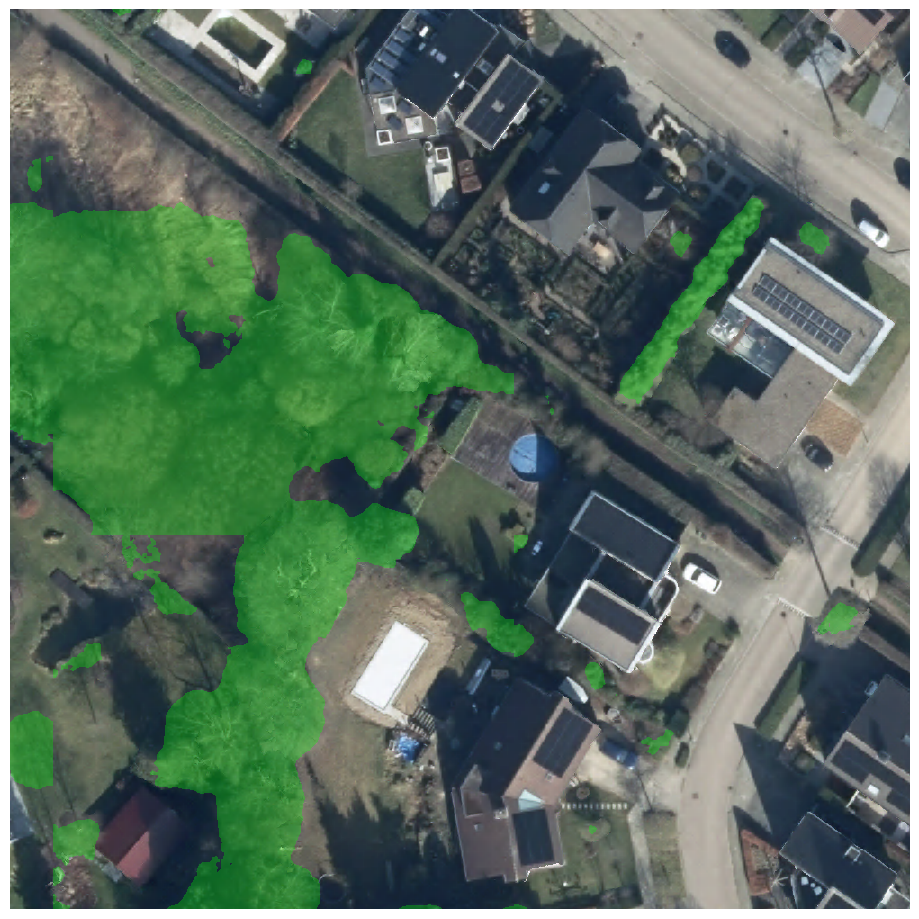

In [14]:
# region to plot among the 10000x10000 image
x_start, x_end = 2000, 3000  
y_start, y_end = 3000, 4000 

# Crop mask and img accordingly
crop_img = full_img[y_start:y_end, x_start:x_end]
crop_mask = full_mask[y_start:y_end, x_start:x_end]

# Create overlay for cropped region 
overlay = crop_img.copy()
overlay[crop_mask == 1] = [0, 255, 0] # ==> positives represented as green
crop_result = (crop_img * 0.7 + overlay * 0.3).astype(np.uint8)

# Plot region 
fig = plt.figure(figsize=(9, 9))
ax = plt.Axes(fig, [0., 0., 1., 1.])
ax.set_axis_off()
fig.add_axes(ax)
ax.imshow(crop_result, interpolation='nearest')
# fig.savefig("cropped_tree_detection.png", dpi=1000, bbox_inches='tight', pad_inches=0)
# plt.close(fig)
plt.show()